In [74]:
def f(x):
    return 2*x**2+3





























In [75]:
def df(x):
    return 4*x+3

In [76]:
def gradient_descent(df,x,lr):
    iter=0
    max_iter=100
    while iter<=max_iter:
        x=x-lr*df(x)
        print(f"for iteration:{iter}")
        iter+=1

    optimal_x=x
    return optimal_x,iter


In [77]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler


In [78]:
file_path="modified_data.csv"

In [79]:
import pandas as pd
df=pd.read_csv(file_path)

| Column             | Meaning                                                   |
| ------------------ | --------------------------------------------------------- |
| **date**           | Date the house was sold/listed                            |
| **price**          | 🏠 Price of the house (**target variable**)               |
| **bedrooms**       | Number of bedrooms                                        |
| **bathrooms**      | Number of bathrooms                                       |
| **sqft_living**    | Living area in square feet                                |
| **sqft_lot**       | Total land/lot area in square feet                        |
| **floors**         | Number of floors                                          |
| **waterfront**     | Whether the house has a waterfront view (0 = No, 1 = Yes) |
| **view**           | Quality/number of views                                   |
| **condition**      | Overall condition of the house                            |
| **sqft_above**     | Square footage above ground                               |
| **sqft_basement**  | Square footage of basement                                |
| **yr_built**       | Year the house was built                                  |
| **yr_renovated**   | Year the house was renovated (0 = not renovated)          |
| **street**         | Street address                                            |
| **city**           | City where the house is located                           |
| **statezip**       | State and ZIP code                                        |
| **price_per_sqft** | Price per square foot                                     |


In [80]:
y = df["price"]
X = df[["sqft_living"]]


In [81]:
(df["price"] == 0).sum()

np.int64(49)

In [82]:
df["price"] = df["price"].replace(0, df["price"].mean())

In [83]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            4600 non-null   str    
 1   price           4600 non-null   float64
 2   bedrooms        4600 non-null   float64
 3   bathrooms       4600 non-null   float64
 4   sqft_living     4600 non-null   int64  
 5   sqft_lot        4600 non-null   int64  
 6   floors          4600 non-null   float64
 7   waterfront      4600 non-null   int64  
 8   view            4600 non-null   int64  
 9   condition       4600 non-null   int64  
 10  sqft_above      4600 non-null   int64  
 11  sqft_basement   4600 non-null   int64  
 12  yr_built        4600 non-null   int64  
 13  yr_renovated    4600 non-null   int64  
 14  street          4600 non-null   str    
 15  city            4600 non-null   str    
 16  statezip        4600 non-null   str    
 17  price_per_sqft  4600 non-null   float64
dtyp

In [84]:

from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

fit->

In [85]:
#fit the model-> fit does the training of the model and finds the best parameters for the model
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[267.22]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['sqft_living']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.605e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [86]:
model.coef_

array([267.22365824])

In [87]:
model.intercept_

np.float64(-26048.209394904785)

In [88]:
y_pred = model.predict(X_test)
y_pred

array([ 364098.33163053,  508399.1070783 ,  759589.3458207 ,
        561843.83872562,  433576.48277205,  727522.50683231,
        540465.94606669,  532449.23631959,  527104.76315486,
        537793.70948432,  783639.475062  ,  227814.26592987,
        834411.97012695,  535121.47290196,  398837.40720129,
        756917.10923834,  692783.43126155,  690111.19467919,
        882512.22860954,  954662.61633342,  724850.27024995,
        703472.37759102,  604599.62404347,  511071.34366066,
        195747.42694147,  182386.24402964,  674077.77518499,
        818378.55063276,  332031.49264214,  652699.88252606,
       1633410.70825439,  299964.65365375, 1221886.27457002,
        588566.20454928,  273242.28783009,  543138.18264906,
        871823.28228008,  962679.32608052,  294620.18048902,
        585893.96796691,  422887.53644259,  374787.27796   ,
        516415.8168254 ,  462971.08517808,  310653.59998321,
        324014.78289504,  487021.21441937,  543138.18264906,
        818378.55063276,

In [89]:
compare = pd.DataFrame({
    "Actual":y_test,
    "Predicted":y_pred}, index=y_test.index)
print(compare.head())

         Actual      Predicted
3683   544000.0  364098.331631
4411        0.0  508399.107078
2584  1712500.0  759589.345821
69     365000.0  561843.838726
1844   275000.0  433576.482772


In [90]:
compare

,Actual,Predicted
3683,544000.0,364098.331631
4411,0.0,508399.107078
2584,1712500.0,759589.345821
69,365000.0,561843.838726
1844,275000.0,433576.482772
...,...,...
1612,750000.0,428232.009607
1068,230000.0,489693.451002
4350,26590000.0,289275.707324
3027,687000.0,607271.860626


In [91]:
print(df.loc[4411, "price"])

551962.9884695652


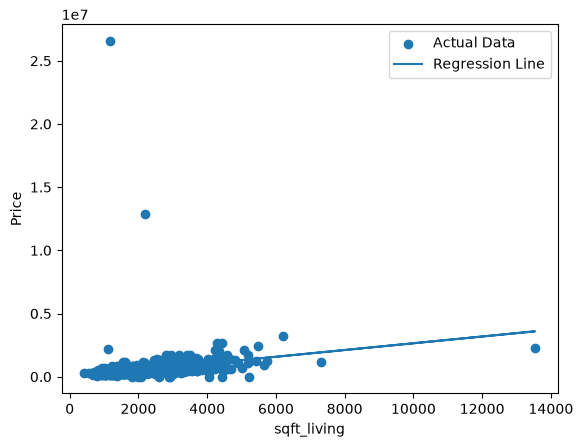

In [ ]:
plt.scatter(X_test, y_test, label="Actual Data")
#Actual house data → dots
plt.plot(X_test, y_pred, label="Regression Line")
#Model's learned relationship → line
plt.xlabel("sqft_living")
plt.ylabel("Price")
plt.legend()

plt.show()

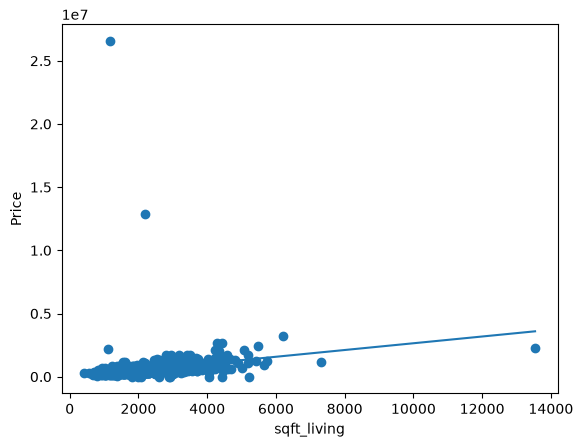

In [93]:
sorted_index = X_test["sqft_living"].argsort()

plt.scatter(X_test["sqft_living"], y_test)

plt.plot(
    X_test["sqft_living"].iloc[sorted_index],
    y_pred[sorted_index]
)

plt.xlabel("sqft_living")
plt.ylabel("Price")
plt.show()

Meaning
Points close to the diagonal → good predictions ✅
Points far from it → prediction errors ❌

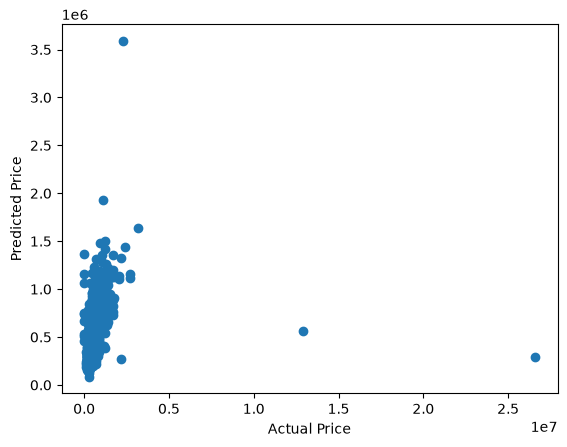

In [94]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.show()

Above zero → model predicted too low
Below zero → model predicted too high
Random scatter around zero → generally good sign ✅
Clear curve/pattern → linear model may not fit well

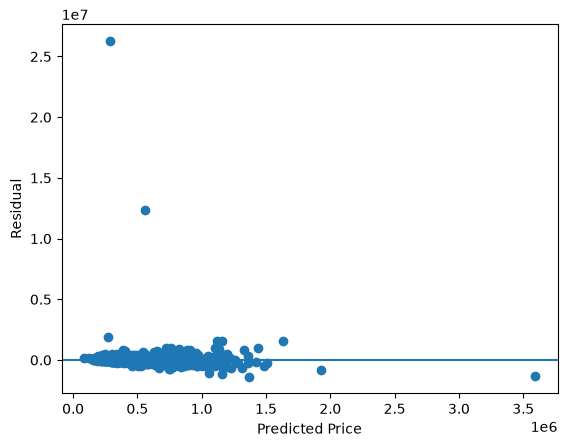

In [95]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)

plt.axhline(y=0)

plt.xlabel("Predicted Price")
plt.ylabel("Residual")

plt.show()

MULTILINEAR REGRESSION

In [96]:
X=df[["sqft_living","sqft_lot","bedrooms","bathrooms","floors","waterfront","view","condition","yr_built","yr_renovated"]]
y=df["price"]

In [97]:
print(X.shape)
print(y.shape)

(4600, 10)
(4600,)


In [98]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [99]:
X_train.head()


,sqft_living,sqft_lot,bedrooms,bathrooms,floors,waterfront,view,condition,yr_built,yr_renovated
1898,2770,45514,4.0,2.50,2.0,0,0,4,1989,0
1370,3720,29043,4.0,3.00,2.0,0,0,3,1991,0
3038,2810,11120,4.0,2.50,2.0,0,0,3,1982,0
2361,4030,10800,4.0,3.75,2.0,0,0,3,2006,0
156,2000,7000,3.0,2.00,2.0,0,0,3,1916,1986


In [100]:
y_train.head()

1898     685000.0
1370     857000.0
3038     675000.0
2361    1485000.0
156      561000.0
Name: price, dtype: float64

In [101]:
model = LinearRegression()

In [102]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[ 280.08, -0.51,-62551.77,..., 31647.37, -2569.35, 9.59]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](10,)","['sqft_living','sqft_lot','bedrooms',...,'condition','yr_built', 'yr_renovated']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.907e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(10)


In [103]:
for i in range(len(model.coef_)):
    print(f"Coefficient for {X.columns[i]}: {model.coef_[i]}")


Coefficient for sqft_living: 280.0752696208801
Coefficient for sqft_lot: -0.5096351147692135
Coefficient for bedrooms: -62551.77469240261
Coefficient for bathrooms: 41271.7877005538
Coefficient for floors: 70814.71548743476
Coefficient for waterfront: 404284.4216080829
Coefficient for view: 47431.57274327371
Coefficient for condition: 31647.368656723236
Coefficient for yr_built: -2569.3516369567556
Coefficient for yr_renovated: 9.593603554203302


In [104]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coefficients)

        Feature    Coefficient
0   sqft_living     280.075270
1      sqft_lot      -0.509635
2      bedrooms  -62551.774692
3     bathrooms   41271.787701
4        floors   70814.715487
5    waterfront  404284.421608
6          view   47431.572743
7     condition   31647.368657
8      yr_built   -2569.351637
9  yr_renovated       9.593604


In [105]:
y_pred = model.predict(X_test)
y_pred

array([ 310874.20903331,  338278.31989747, 1092848.35929845,
        556503.83482752,  390177.23848498,  607776.36896175,
        491128.40705789,  422944.34122096,  514578.09772928,
        536001.7169525 ,  685526.85682778,  418590.49860357,
        839647.0018132 ,  422788.84285219,  367226.68845563,
        725034.08138818,  684388.81229314,  517500.81578436,
       1035330.30311901,  860916.00273964, 1401016.52130949,
        639701.05824867,  641518.80248476,  477018.76105952,
        160988.17727005,  230906.64928031,  670562.60351082,
        889755.81449789,  263417.54120313,  990480.87109978,
       1912669.27855623,  486972.20671185, 1285533.37361169,
        441338.06840072,  184936.62392218,  351685.03967953,
        792787.05202544, 1037150.91473401,  236865.57383321,
        544957.0938719 ,  426703.55160042,  242658.97357197,
        393784.60936994,  369935.53394307,  324063.16262611,
        319128.05273851,  474247.69247064,  587481.82526783,
        840149.99517715,

How close are predicted house prices to actual house prices?

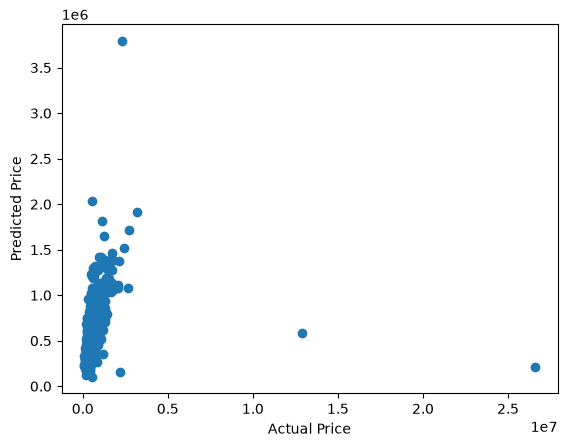

In [106]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.show()

Underpredicting
Overpredicting
Making systematic errors

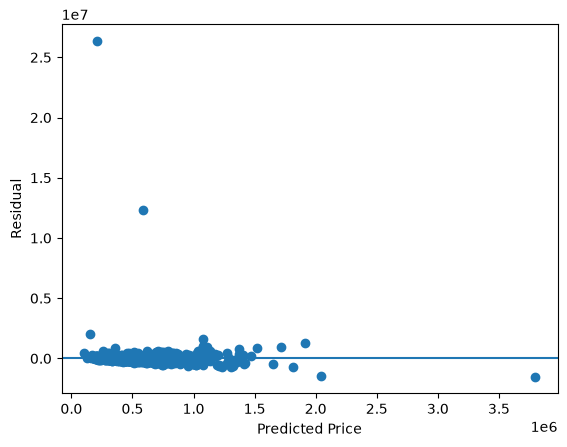

In [107]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)

plt.axhline(y=0)

plt.xlabel("Predicted Price")
plt.ylabel("Residual")

plt.show()

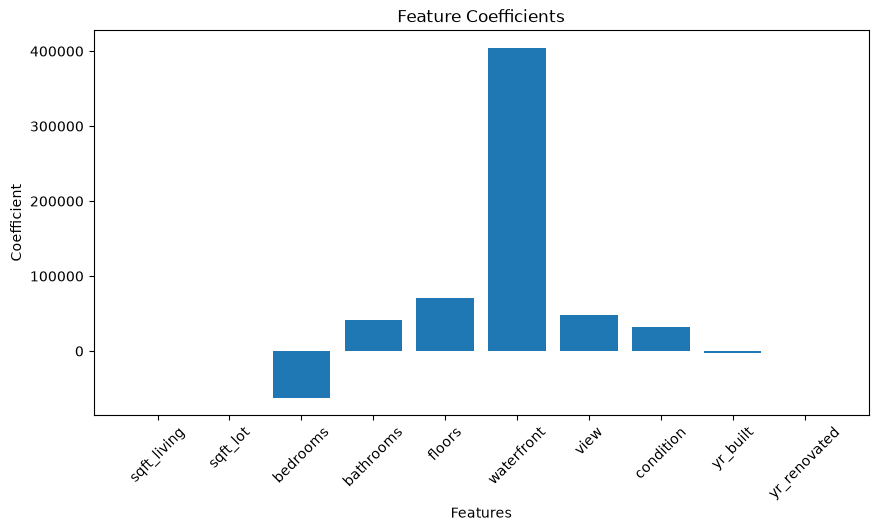

In [109]:
plt.figure(figsize=(10, 5))

plt.bar(coefficients["Feature"], coefficients["Coefficient"])

plt.xticks(rotation=45)

plt.xlabel("Features")
plt.ylabel("Coefficient")

plt.title("Feature Coefficients")

plt.show()

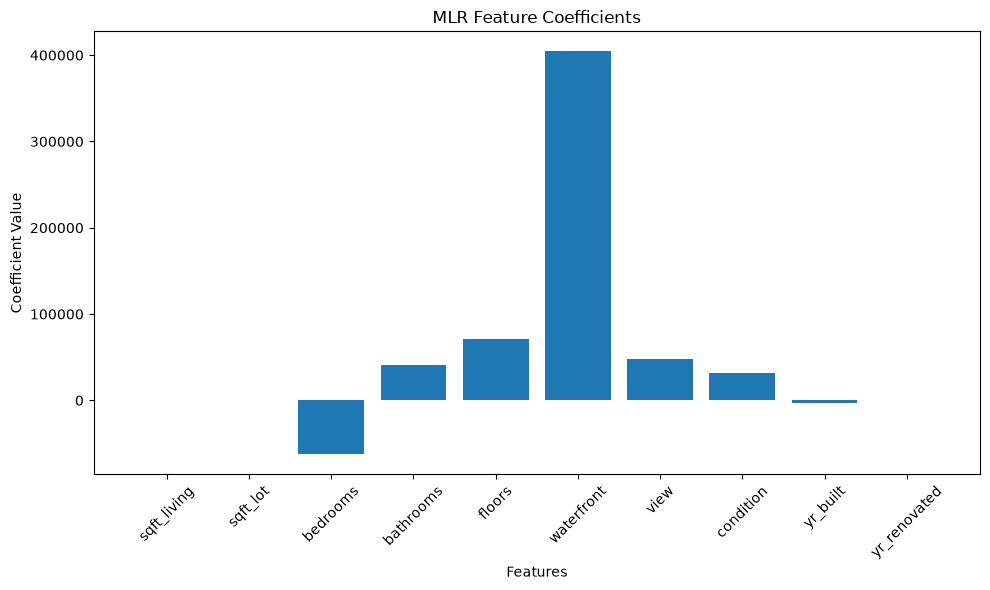

In [108]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    coefficients["Feature"],
    coefficients["Coefficient"]
)

plt.xlabel("Features")
plt.ylabel("Coefficient Value")
plt.title("MLR Feature Coefficients")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()